**Customer Churn Prediction**

# **Importing the dependencies**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv('/content/Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df = df.drop(['CustomerId'], axis=1)
df

,RowNumber,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
#Printing the unique in all the columns
numerical_feacture_list = ['RowNumber', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for col in df.columns:
  if col not in numerical_feacture_list:
    print(f'{col}: {df[col].unique()}')
    print('-'*50)

Surname: ['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
--------------------------------------------------
Geography: ['France' 'Spain' 'Germany']
--------------------------------------------------
Gender: ['Female' 'Male']
--------------------------------------------------
HasCrCard: [1 0]
--------------------------------------------------
IsActiveMember: [1 0]
--------------------------------------------------
Exited: [1 0]
--------------------------------------------------


In [ ]:
print(df.isnull().sum())

RowNumber          0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
#checking the class distribution of target columns
print(df['Exited'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


# **Exploratory data analysis(EDA)**

In [ ]:
df.shape

(10000, 13)

In [ ]:
df.columns

Index(['RowNumber', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df.describe()

,RowNumber,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## **Numerical Features Analysis**

In [ ]:
def plot_histogram(df, column_name):
  plt.figure(figsize=(10, 6))
  sns.histplot(df[column_name], kde=True)
  plt.title("distribution of {}".format(column_name))
  plt.show()

  # Calculate the mean and median values for the median
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines foir mean and median
  plt.axvline(col_mean, color='red', linestyle='dashed', label="Mean")
  plt.axvline(col_median, color='blue', linestyle='dashed', label="Median")

  # add legend and show the plot
  plt.legend()

  plt.show()

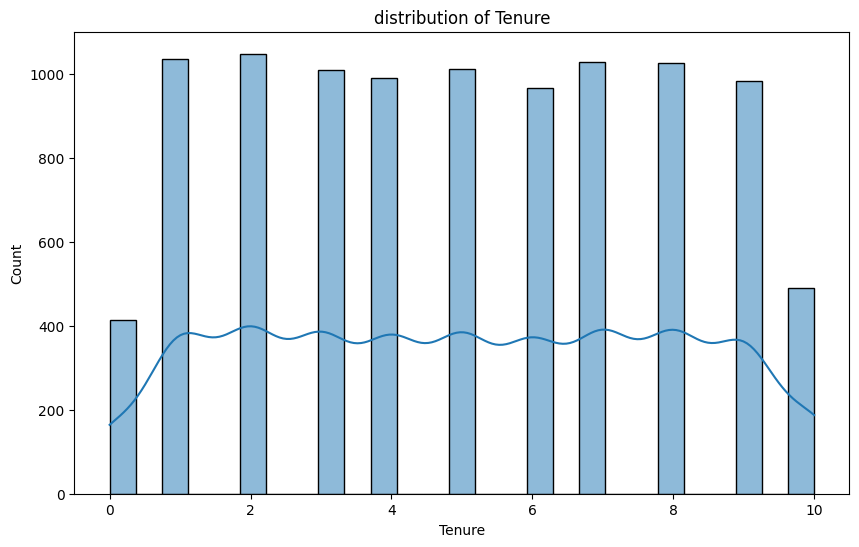

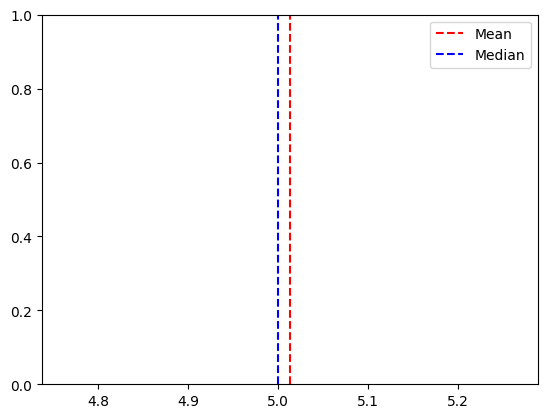

In [ ]:
plot_histogram(df, "Tenure")

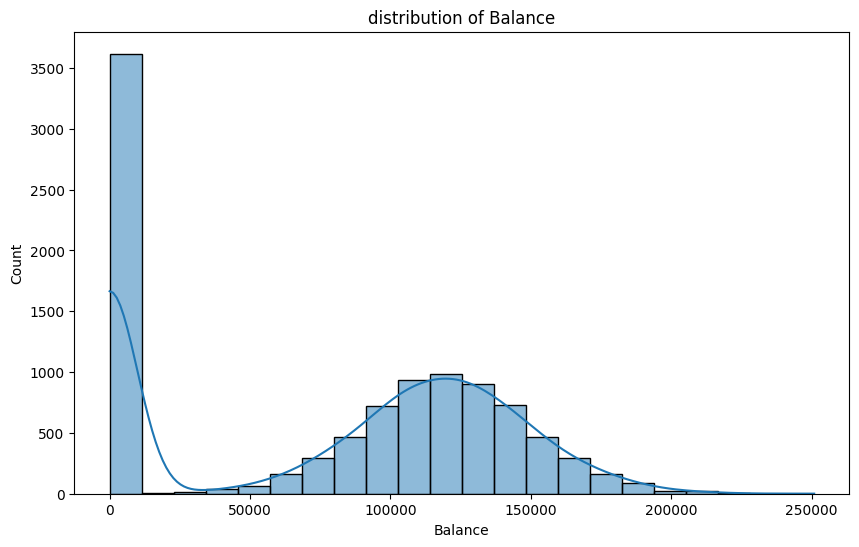

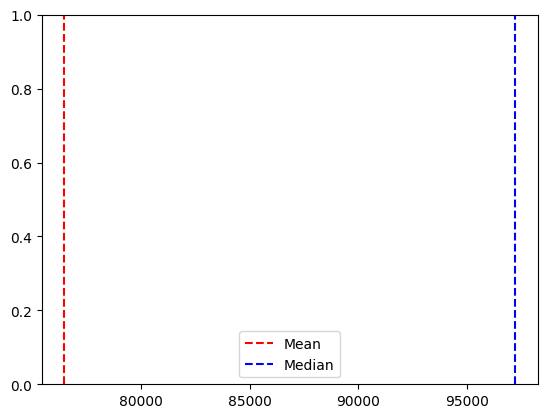

In [ ]:
plot_histogram(df, "Balance")

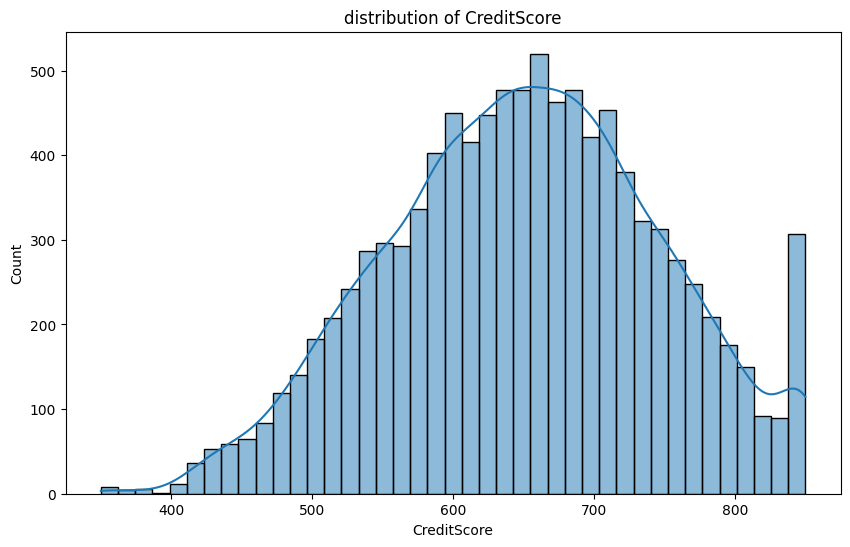

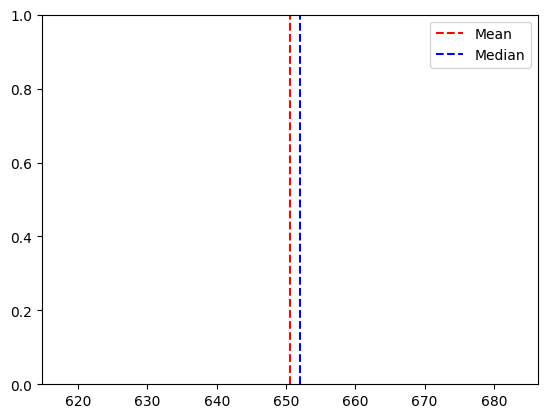

In [ ]:
plot_histogram(df, "CreditScore")

**Box plot numerical feature**

In [ ]:
def plot_boxplot(df, column_name):
  plt.figure(figsize=(10, 6))
  sns.boxplot(x=df[column_name])
  plt.title("distribution of (column_name)")
  plt.ylabel(column_name)
  plt.show()

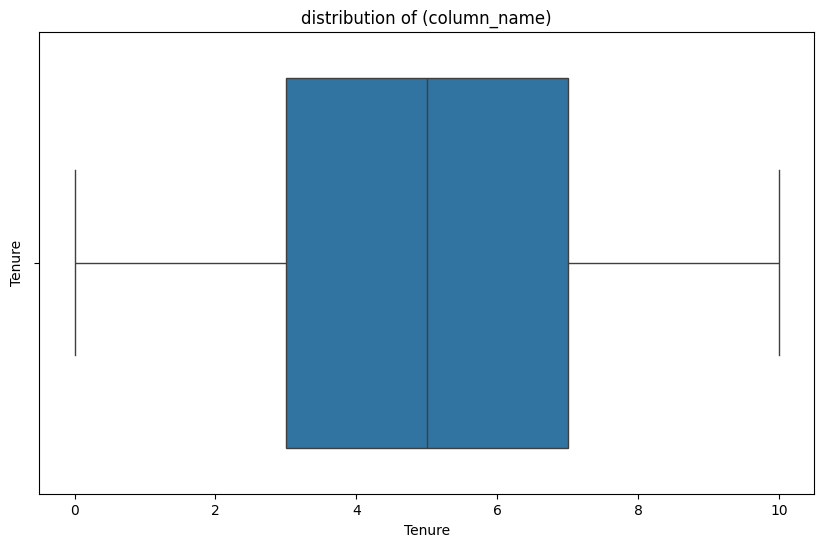

In [ ]:
plot_boxplot(df, 'Tenure')

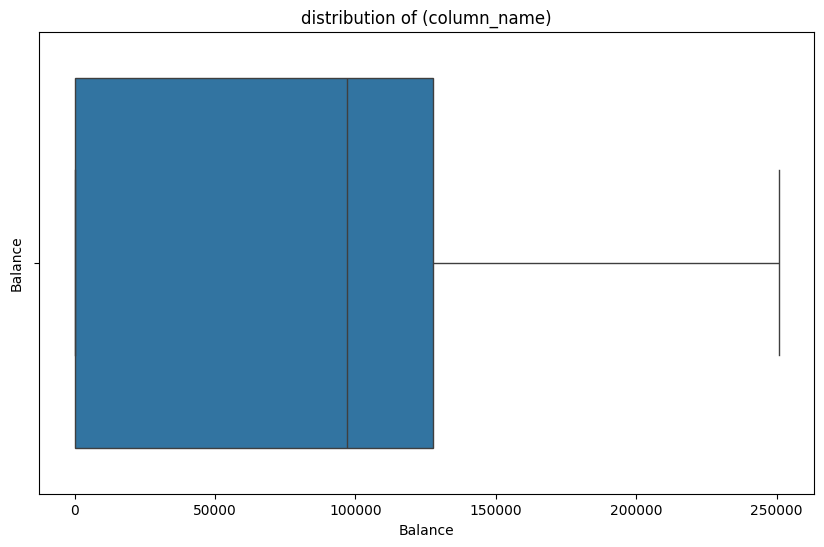

In [ ]:
plot_boxplot(df, "Balance")

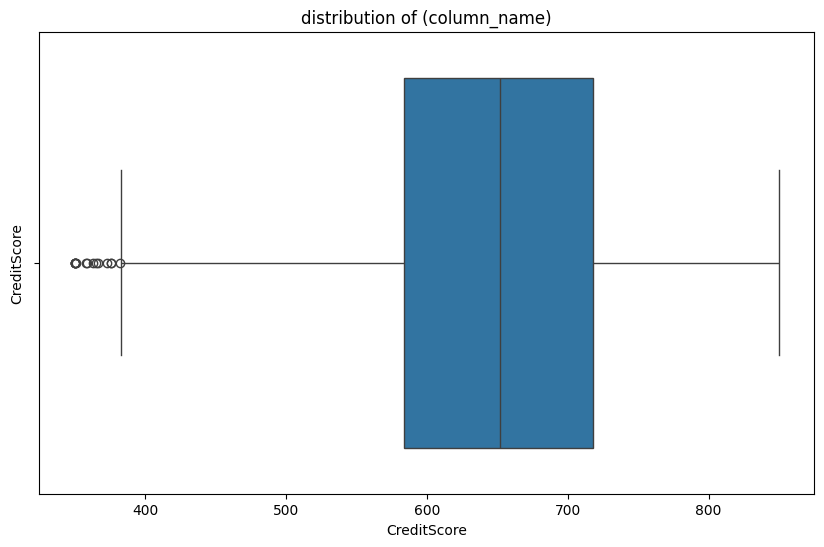

In [ ]:
plot_boxplot(df, "CreditScore")

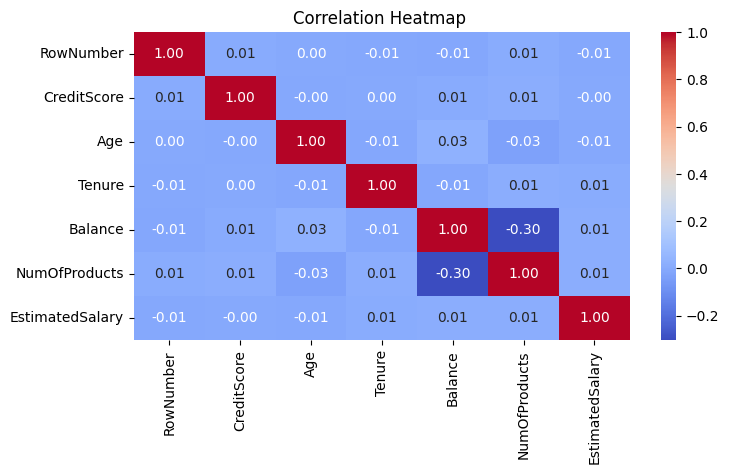

In [ ]:
#Correlation Heatmap for Numerical Columns

plt.figure(figsize=(8, 4))
sns.heatmap(df[['RowNumber', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap ")
plt.show()

## **Categorical Features-Analysis**

In [ ]:
df.columns

Index(['RowNumber', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


##  **Countplot for Categorical Columns**

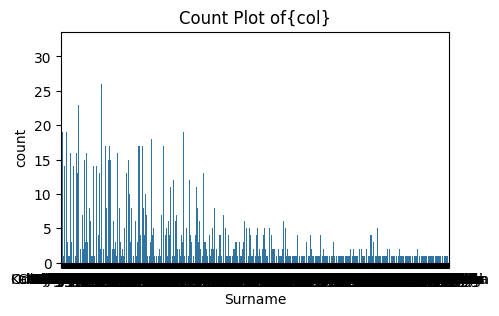

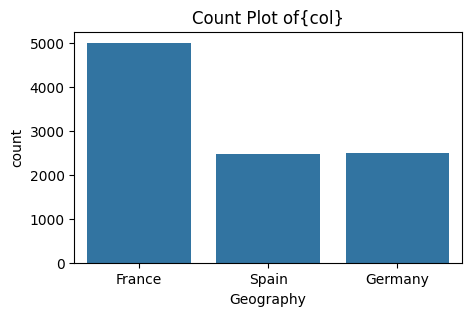

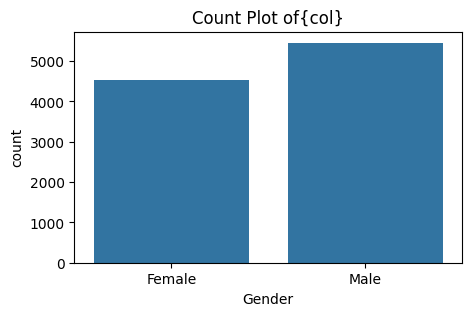

In [ ]:
object_cols = df.select_dtypes(include=['object']).columns.tolist()
object_cols

for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title("Count Plot of{col}")
  plt.show()

#**Data Preprocessing**

In [ ]:
df.head(3)

,RowNumber,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


Label encoding of target column

In [ ]:
df['Exited'] = df['Exited'].replace({'Yes':1, 'No':0})

In [ ]:
df.head(3)

,RowNumber,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [ ]:
print(df['Exited'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [ ]:
#Identifying columns with object data type
object_columns = df.select_dtypes(include=['object']).columns
print(object_columns)

Index(['Surname', 'Geography', 'Gender'], dtype='object')


In [ ]:
from pickleshare import pickle
#initialize a dictionary to save the encoders
encoders = {}

#apply labels encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder

  #save the encoders to a pickle file
  with open("encoders.pk1","wb")as f:
    pickle.dump(encoders, f)


In [ ]:
encoders

{'Surname': LabelEncoder(),
 'Geography': LabelEncoder(),
 'Gender': LabelEncoder()}

In [ ]:
df.head()

,RowNumber,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,1115,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,1177,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,2040,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,289,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,1822,850,2,0,43,2,125510.82,1,1,1,79084.10,0


## **Split the Data**

In [ ]:
#splitting the features and target
x = df.drop(columns=['Exited'])
y = df['Exited']
print(x)

      RowNumber  Surname  CreditScore  Geography  Gender  Age  Tenure  \
0             1     1115          619          0       0   42       2   
1             2     1177          608          2       0   41       1   
2             3     2040          502          0       0   42       8   
3             4      289          699          0       0   39       1   
4             5     1822          850          2       0   43       2   
...         ...      ...          ...        ...     ...  ...     ...   
9995       9996     1999          771          0       1   39       5   
9996       9997     1336          516          0       1   35      10   
9997       9998     1570          709          0       0   36       7   
9998       9999     2345          772          1       1   42       3   
9999      10000     2751          792          0       0   28       4   

        Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  
0          0.00              1          1     

In [ ]:

x = df.drop(columns=['Exited'])
y = df['Exited']
print(y)

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64


In [ ]:
x_train, x_test,y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print(y_train.shape)

(8000,)


Synthetic Minority Overstampling Technique(SMOTE)

In [ ]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [ ]:
print(y_train_smote.shape)

(12712,)


In [ ]:
print(y_train_smote.value_counts())

Exited
0    6356
1    6356
Name: count, dtype: int64


# **Model Training**

Training with default hyperparameters

In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

In [ ]:
#dictionary to store the cross validation results
cv_scores = {}

#perform cross validation and store the results
for model_name, model in models.items():
  print(f"Training {model_name}...")
  scores = cross_val_score(model, x_train_smote, y_train_smote, cv=5, scoring='accuracy')
  cv_scores[model_name] = scores
  print(f"{model_name} cross validation accuracy: {np.mean(scores):2f}")
  print('-'*70)

Training Decision Tree...
Decision Tree cross validation accuracy: 0.787216
----------------------------------------------------------------------
Training Random Forest...
Random Forest cross validation accuracy: 0.861163
----------------------------------------------------------------------
Training XGBoost...
XGBoost cross validation accuracy: 0.864545
----------------------------------------------------------------------


In [ ]:
cv_scores


{'Decision Tree': array([0.70035391, 0.78372002, 0.81785995, 0.81667978, 0.81746656]),
 'Random Forest': array([0.75619347, 0.86747936, 0.90086546, 0.88276947, 0.89850511]),
 'XGBoost': array([0.76130554, 0.87062525, 0.9036192 , 0.89181747, 0.89535799])}

Random Forest gives the highest accuracy compared to other models default parameters

In [ ]:
rfc = RandomForestClassifier(random_state=42)

In [ ]:
rfc.fit(x_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

# **Model Evaluation**

In [ ]:
#evaluate on test data
y_test_pred =  rfc.predict(x_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.8285
Confusion Matrix:
 [[1409  198]
 [ 145  248]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89      1607
           1       0.56      0.63      0.59       393

    accuracy                           0.83      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.84      0.83      0.83      2000



In [ ]:
#save the trained model as pickle file
model_data = {"model":rfc, "feature_names":x.columns.tolist()}

with open("customer_churn_model.pk1", "wb") as f:
  pickle.dump(rfc, f)

# **Load the saved  model and bulid the predictive system**

In [ ]:
#load to saved model and the feature names

with open("customer_churn_model.pk1", "rb") as f:
  model = pickle.load(f)

  laoded_model = model_data["model"]
  feature_names = model_data["feature_names"]

  print(laoded_model)

RandomForestClassifier(random_state=42)


In [ ]:
print(feature_names)

['RowNumber', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [ ]:
input_data = {
    'RowNumber': 1,
    'Surname': 'Hargrave', # Provide the original string value for Surname
    'CreditScore': 619,
    'Geography': 'France', # Provide the original string value for Geography
    'Gender': 'Female', # Provide the original string value for Gender
    'Age': 42,
    'Tenure': 2,
    'Balance': 0.0,
    'NumOfProducts': 1,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 101348.88
}

input_data_df = pd.DataFrame([input_data])

with open("encoders.pk1", "rb") as f:
  encoders = pickle.load(f)
print(input_data_df.head())

#encode categorical features using the saved encoders
for column, encoder in encoders.items():
  # Ensure the column exists in input_data_df before attempting to transform
  if column in input_data_df.columns:
    input_data_df[column] = encoder.transform(input_data_df[column])

#make a prediction
prediction = model.predict(input_data_df)
pred_prob = model.predict_proba(input_data_df)

print(prediction)

#result
print(f"Prediction: {'Exited' if prediction[0] == 1 else 'No Exited'}")
print(f"Prdiction Probability: {pred_prob}")


   RowNumber   Surname  CreditScore Geography  Gender  Age  Tenure  Balance  \
0          1  Hargrave          619    France  Female   42       2      0.0   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  
0              1          1               1        101348.88  
[0]
Prediction: No Exited
Prdiction Probability: [[0.63 0.37]]
